# Homework #3: Discrete Event Simulation

In [184]:
# Imports
import simpy
from numpy.random import default_rng
from scipy.stats import expon
import pandas as pd
import matplotlib.pyplot as plt


I have traveled internationally many times, and I am always intrigued by the differences in waiting time between the security screening processes at different airports. Airport security is a balance between being thorough and being quick, and some places just seem to find that balance better than others.

My home city of Detroit, which is a Delta hub, is extremely quick and efficient. The whole security process rarely takes longer than 10-15 minutes even on a busy flying day. However, London's Heathrow airport is the exact opposite. No matter what, I always find myself waiting upwards of half an hour (or longer), even on less common travel days.

It doesn't help that Heathrow is one of the busiest airports in the world, but they also clearly have a lot more capacity than Detroit does. With all of that stated, I'm curious about exploring the bottlenecks that can develop in these types of situations.

### How will this system work?

Travelers will arrive in the queue for security at random intervals based on a predetermined rate. If one is available, a security team member will check their passport and boarding pass. Otherwise, the traveler will have to wait until they can be serviced.

Next, the traveler enters another queue. Once they are at the front, a security team member will instruct them to place their items onto the conveyor belt. The traveler may stop to ask questions ("Should I take my shoes off going throuh the x-ray machine?"), so the time this takes could be longer for some travelers.

The traveler then goes through the metal detector (which has a limited queue size). Simultaneously, their items go through the scanner (again, a limited queue size). There is a chance that either could be flagged for additional screening. The traveler can only collect their belongings once the items have been fully processed, so both events must be finished before the next can commence.

Finally, the traveler gets their items, and takes a few extra seconds to get things in order before leaving the security area.

### Create the Security class

We can create a security class that includes input parameters and  and establishes the number of employees in each role.

In [156]:
class Security(object):
    def __init__(self, env, num_passport_reviewers, num_pre_screening_helpers,
                 num_human_xray_reviewers, num_bag_xray_reviewers, rg):
        # Simulation environment
        self.env = env
        self.rg = rg
        
        # Create list to hold timestamps dictionaries (one per traveler)
        self.timestamps_list = []
        # Create lists to hold occupancy tuples (time, occ)
        self.postxray_occupancy_list = [(0.0, 0.0)]
        self.xray_occupancy_list = [(0.0, 0.0)]
        self.bag_xray_occupancy_list = [(0.0, 0.0)]
        
        # Create resources
        self.passport_reviewer = simpy.Resource(env, num_passport_reviewers)
        self.pre_screening_helper = simpy.Resource(env, num_pre_screening_helpers)
        self.human_xray_reviewer = simpy.Resource(env, num_human_xray_reviewers)
        self.bag_xray_reviewer = simpy.Resource(env, num_bag_xray_reviewers)

    # Create process methods
    def passport_check(self, traveler):
        yield self.env.timeout(self.rg.normal(1.0, 0.2))

    def item_loading(self, traveler):
        yield self.env.timeout(self.rg.exponential(0.5))

    def human_xray_scan(self, traveler):
        yield self.env.timeout(self.rg.exponential(0.5))
        
    def bag_xray_scan(self, traveler):
        yield self.env.timeout(self.rg.exponential(0.5))

    # If additional screening is required, that will take more time
    def additional_screening(self, traveler):
        yield self.env.timeout(self.rg.normal(5.0, 1.0))
    
    # Some travelers take longer to leave than others after they have been screened
    # They will take at least half a minute, which is configured elsewhere
    def get_items_and_leave(self, traveler):
        yield self.env.timeout(self.rg.exponential(0.5))

### Create the get_screened Function

This function defines the sequence of steps that travelers will go through, requests and releases staff resources, and takes timestamps when events occur.

If someone requires additional screening, that utilizes the human/baggage xray reviewers as the standard line.

In [176]:
def get_screened(env, traveler, security, pct_additional_screening, rg):
    # traveler arrives to security - note the arrival time
    arrival_ts = env.now

    # Request a passport reviewer for boarding pass/passport check
    # By using request() in a context manager, we'll automatically release the resource when done
    with security.passport_reviewer.request() as request:
        yield request
        # Now that we have a passport reviewer, check the boarding pass/passport. Note time.
        got_passport_reviewer_ts = env.now
        yield env.process(security.passport_check(traveler))
        release_passport_reviewer_ts = env.now

    # Request staff to help with pre-screening
    with security.pre_screening_helper.request() as request:
        yield request
        got_prescreen_help_ts = env.now
        yield env.process(security.item_loading(traveler))
        release_prescreen_help_ts = env.now

    # Initialize parallel timestamps (local variables get a NameError)
    got_xray_reviewer_ts = pd.NA
    release_xray_reviewer_ts = pd.NA
    got_add_xray_reviewer_ts = pd.NA
    release_add_xray_reviewer_ts = pd.NA
    got_bag_xray_reviewer_ts = pd.NA
    release_bag_xray_reviewer_ts = pd.NA
    got_add_bag_xray_reviewer_ts = pd.NA
    release_add_bag_xray_reviewer_ts = pd.NA
        
    # Request security staff to xray the traveler
    def human_branch():
        # Identify nonlocal variables
        nonlocal got_xray_reviewer_ts, release_xray_reviewer_ts, got_add_xray_reviewer_ts, release_add_xray_reviewer_ts
        
        with security.human_xray_reviewer.request() as request:
            yield request
            got_xray_reviewer_ts = env.now
            # Update xray occupancy - increment by 1
            prev_occ = security.xray_occupancy_list[-1][1]
            new_occ = (env.now, prev_occ + 1)
            security.xray_occupancy_list.append(new_occ)
            yield env.process(security.human_xray_scan(traveler))
            release_xray_reviewer_ts = env.now
            # Update xray occupancy - decrement by 1 - more compact code
            security.xray_occupancy_list.append((env.now, security.xray_occupancy_list[-1][1] - 1))
            
            # Update postxray occupancy - increment by 1
            security.postxray_occupancy_list.append((env.now, security.postxray_occupancy_list[-1][1] + 1))

        # Request human xray reviewer if additional screening is required
        if rg.random() < pct_additional_screening:
            with security.human_xray_reviewer.request() as request:
                yield request
                got_add_xray_reviewer_ts = env.now
                yield env.process(security.additional_screening(traveler))
                release_add_xray_reviewer_ts = env.now
        else:
            got_add_xray_reviewer_ts = pd.NA
            release_add_xray_reviewer_ts = pd.NA

    # Request security staff to xray the bag
    def bag_branch():
        # Identify nonlocal variables
        nonlocal got_bag_xray_reviewer_ts, release_bag_xray_reviewer_ts, got_add_bag_xray_reviewer_ts, release_add_bag_xray_reviewer_ts
        
        with security.bag_xray_reviewer.request() as request:
            yield request
            got_bag_xray_reviewer_ts = env.now
            # Update xray occupancy - increment by 1
            prev_occ = security.bag_xray_occupancy_list[-1][1]
            new_occ = (env.now, prev_occ + 1)
            security.bag_xray_occupancy_list.append(new_occ)
            yield env.process(security.bag_xray_scan(traveler))
            release_bag_xray_reviewer_ts = env.now
            # Update xray occupancy - decrement by 1 - more compact code
            security.bag_xray_occupancy_list.append((env.now, security.bag_xray_occupancy_list[-1][1] - 1))

        # Request bag xray reviewer if additional screening is required
        if rg.random() < pct_additional_screening:
            with security.bag_xray_reviewer.request() as request:
                yield request
                got_add_bag_xray_reviewer_ts = env.now
                yield env.process(security.additional_screening(traveler))
                release_add_bag_xray_reviewer_ts = env.now
        else:
            got_add_xray_reviewer_ts = pd.NA
            release_add_bag_xray_reviewer_ts = pd.NA

    # Trigger both the human and bag branches simultaneously and wait for them to both finish
    p_human = env.process(human_branch())
    p_bag = env.process(bag_branch())
    yield p_human & p_bag

    # We can't leave until both the human and bag screenings have finished
    finish_times = [release_xray_reviewer_ts, release_bag_xray_reviewer_ts]
    # Account for additional screening if either occurred
    if not pd.isna(release_add_xray_reviewer_ts):
        finish_times.append(release_add_xray_reviewer_ts)
    if not pd.isna(release_add_bag_xray_reviewer_ts):
        finish_times.append(release_add_bag_xray_reviewer_ts)
    # Get the later time of the two
    last_screening_finish = max(finish_times)
        
    # Wait at least half a minute from time we finished getting screened
    post_screen_time = env.now - last_screening_finish
    if post_screen_time < 0.5:
        # Wait until at least half a minute
        yield env.timeout(0.5 - post_screen_time)
        # Wait random amount beyond half a minute
        yield env.process(security.get_items_and_leave(traveler))
        exit_system_ts = env.now
        
        # Update postxray occupancy - decrement by 1
        security.postxray_occupancy_list.append((env.now, security.postxray_occupancy_list[-1][1] - 1))
    
    exit_system_ts = env.now    
    #print(f"traveler {traveler} exited at time {env.now}")

    # Create dictionary of timestamps
    timestamps = {'traveler_id': traveler,
                  'arrival_ts': arrival_ts,
                  'got_passport_reviewer_ts': got_passport_reviewer_ts,
                  'release_passport_reviewer_ts': release_passport_reviewer_ts,
                  'got_prescreen_help_ts': got_prescreen_help_ts,
                  'release_prescreen_help_ts': release_prescreen_help_ts,
                  'got_xray_reviewer_ts': got_xray_reviewer_ts,
                  'release_xray_reviewer_ts': release_xray_reviewer_ts,
                  'got_bag_xray_reviewer_ts': got_bag_xray_reviewer_ts,
                  'release_bag_xray_reviewer_ts': release_bag_xray_reviewer_ts,
                  'got_add_xray_reviewer_ts': got_add_xray_reviewer_ts,
                  'release_add_xray_reviewer_ts': release_add_bag_xray_reviewer_ts,
                  'got_add_bag_xray_reviewer_ts': got_add_xray_reviewer_ts,
                  'release_add_bag_xray_reviewer_ts': release_add_bag_xray_reviewer_ts,
                  'last_screening_finish': last_screening_finish,
                  'exit_system_ts': exit_system_ts}
    
    security.timestamps_list.append(timestamps)

### Create the run_security Function

This function will generate travelers for the system for a specified amount of time. It utilizes a exponential/Poisson distribution for arrival times.

In [120]:
def run_security(env, security, mean_interarrival_time, pct_additional_screening, rg, 
               stoptime=simpy.core.Infinity, max_arrivals=simpy.core.Infinity):
      
    # Create a counter to keep track of number of travelers generated and to serve as unique traveler id
    traveler = 0

    # Loop for generating travelers
    while env.now < stoptime and traveler < max_arrivals:

        # Generate next interarrival time (this will be more complicated later)
        iat = rg.exponential(mean_interarrival_time)
        
        # This process will now yield to a 'timeout' event. This process will resume after iat time units.
        yield env.timeout(iat)

        # New traveler generated = update counter of travelers
        traveler += 1
        
        #print(f"traveler {traveler} created at time {env.now}")

        env.process(get_screened(env, traveler, security, pct_additional_screening, rg))

### Create and run the main Function

This function establishes the input values, number of staff in each role, and outputs .csv files with timestamps in them.

In [144]:
def main(parameters):
    # Get parameter values
    travelers_per_hour = parameters['travelers_per_hour']
    pct_additional_screening = parameters['pct_additional_screening']
    rg = parameters['rg']
    num_passport_reviewer = parameters['num_passport_reviewer']
    num_pre_screening_helper = parameters['num_pre_screening_helper']
    num_human_xray_reviewer = parameters['num_human_xray_reviewer']
    num_bag_xray_reviewers = parameters['num_bag_xray_reviewers']
    stoptime = parameters['stoptime']
    
    # Calculate traveler arrival rate
    mean_interarrival_time = 1.0 / (travelers_per_hour / 60.0)
    
    # Create a simulation environment
    env = simpy.Environment()
    # Create a security to simulate
    security = Security(env, num_passport_reviewer, num_pre_screening_helper,
                        num_human_xray_reviewer, num_bag_xray_reviewers, rg)
    
    # Register the run_security (generator) function
    env.process(run_security(env, security, mean_interarrival_time, pct_additional_screening, rg, stoptime=stoptime))
    # Actually run the simulation
    env.run()
    
    # The simulation is over now, let's create the output csv files from 
    # the dataframes created by running the simulation model.
    
    # Output log files 
    security_traveler_log_df = pd.DataFrame(security.timestamps_list)
    security_traveler_log_df.to_csv('./output/security_traveler_log_df.csv', index=False)
    
    xray_occupancy_df = pd.DataFrame(security.xray_occupancy_list, columns=['ts', 'occ'])
    xray_occupancy_df.to_csv('./output/xray_occupancy_df.csv', index=False)
    
    postxray_occupancy_df = pd.DataFrame(security.postxray_occupancy_list, columns=['ts', 'occ'])
    postxray_occupancy_df.to_csv('./output/postxray_occupancy_df.csv', index=False)
    
    # Note simulation end time
    end_time = env.now
    print(f"Simulation ended at time {end_time}")
    return (end_time)

In [177]:
# Define parameters
parameters = {
    # Traveler arrival rate
    'travelers_per_hour': 600,
    'pct_additional_screening': 0.05,
    # Create a random number generator
    'rg': default_rng(seed=2503),
    'num_passport_reviewer': 8,
    # Resource capacity levels
    'num_pre_screening_helper': 4,
    'num_human_xray_reviewer': 8,
    'num_bag_xray_reviewers': 8,
    # Hours of operation
    'stoptime': 600 # No more arrivals after this time
}

In [178]:
# Run the system!
security_end_time = main(parameters)

Simulation ended at time 759.1785645653615


Whoops, we seem to have taken 160 extra minutes to get everyone through. What's causing that to happen?

### Analyzing the timestamp files

Let's load the timestamps file.

In [179]:
security_traveler_log_df = pd.read_csv('./output/security_traveler_log_df.csv')
security_traveler_log_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6005 entries, 0 to 6004
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   traveler_id                       6005 non-null   int64  
 1   arrival_ts                        6005 non-null   float64
 2   got_passport_reviewer_ts          6005 non-null   float64
 3   release_passport_reviewer_ts      6005 non-null   float64
 4   got_prescreen_help_ts             6005 non-null   float64
 5   release_prescreen_help_ts         6005 non-null   float64
 6   got_xray_reviewer_ts              6005 non-null   float64
 7   release_xray_reviewer_ts          6005 non-null   float64
 8   got_bag_xray_reviewer_ts          6005 non-null   float64
 9   release_bag_xray_reviewer_ts      6005 non-null   float64
 10  got_add_xray_reviewer_ts          286 non-null    float64
 11  release_add_xray_reviewer_ts      317 non-null    float64
 12  got_add_bag_xray_

In [180]:
security_traveler_log_df.head()

,traveler_id,arrival_ts,got_passport_reviewer_ts,release_passport_reviewer_ts,got_prescreen_help_ts,release_prescreen_help_ts,got_xray_reviewer_ts,release_xray_reviewer_ts,got_bag_xray_reviewer_ts,release_bag_xray_reviewer_ts,got_add_xray_reviewer_ts,release_add_xray_reviewer_ts,got_add_bag_xray_reviewer_ts,release_add_bag_xray_reviewer_ts,last_screening_finish,exit_system_ts
0,3,0.199507,0.199507,1.017951,1.017951,1.241409,1.241409,1.382449,1.241409,1.697971,NaN,NaN,NaN,NaN,1.697971,2.385790
1,5,0.381618,0.381618,1.847026,1.847026,2.020824,2.020824,2.467233,2.020824,2.141221,NaN,NaN,NaN,NaN,2.467233,3.168061
2,2,0.169542,0.169542,1.090644,1.090644,1.369819,1.369819,1.748612,1.369819,2.612658,NaN,NaN,NaN,NaN,2.612658,3.335756
3,11,0.943364,1.055320,1.528715,1.528715,1.624676,1.624676,2.471400,1.624676,2.469566,NaN,NaN,NaN,NaN,2.471400,3.387239
4,10,0.868318,1.017951,2.030586,2.030586,2.108804,2.108804,2.444495,2.108804,2.574572,NaN,NaN,NaN,NaN,2.574572,3.662732


Let's compute the durations of each section.

In [181]:
def compute_durations(timestamp_df):
    
    timestamp_df['wait_for_passport_viewer'] = timestamp_df.loc[:, 'got_passport_reviewer_ts'] - timestamp_df.loc[:, 'arrival_ts']
    timestamp_df['wait_for_prescreen_help'] = timestamp_df.loc[:, 'got_prescreen_help_ts'] - timestamp_df.loc[:, 'release_passport_reviewer_ts']
    timestamp_df['wait_for_human_xray'] = timestamp_df.loc[:, 'got_xray_reviewer_ts'] - timestamp_df.loc[:, 'release_prescreen_help_ts']
    timestamp_df['wait_for_bag_xray'] = timestamp_df.loc[:, 'got_bag_xray_reviewer_ts'] - timestamp_df.loc[:, 'release_prescreen_help_ts']
    timestamp_df['wait_for_baggage'] = timestamp_df.loc[:, 'last_screening_finish'] - timestamp_df.loc[:, 'release_xray_reviewer_ts']
    timestamp_df['post_xray_time'] = timestamp_df.loc[:, 'exit_system_ts'] - timestamp_df.loc[:, 'last_screening_finish']
    timestamp_df['time_in_system'] = timestamp_df.loc[:, 'exit_system_ts'] - timestamp_df.loc[:, 'arrival_ts']
    
    return timestamp_df

In [182]:
security_traveler_log_df = compute_durations(security_traveler_log_df)
security_traveler_log_df

,traveler_id,arrival_ts,got_passport_reviewer_ts,release_passport_reviewer_ts,got_prescreen_help_ts,release_prescreen_help_ts,got_xray_reviewer_ts,release_xray_reviewer_ts,got_bag_xray_reviewer_ts,release_bag_xray_reviewer_ts,...,release_add_bag_xray_reviewer_ts,last_screening_finish,exit_system_ts,wait_for_passport_viewer,wait_for_prescreen_help,wait_for_human_xray,wait_for_bag_xray,wait_for_baggage,post_xray_time,time_in_system
0,3,0.199507,0.199507,1.017951,1.017951,1.241409,1.241409,1.382449,1.241409,1.697971,...,NaN,1.697971,2.385790,0.000000,0.000000,0.0,0.0,0.315522,0.687819,2.186283
1,5,0.381618,0.381618,1.847026,1.847026,2.020824,2.020824,2.467233,2.020824,2.141221,...,NaN,2.467233,3.168061,0.000000,0.000000,0.0,0.0,0.000000,0.700829,2.786443
2,2,0.169542,0.169542,1.090644,1.090644,1.369819,1.369819,1.748612,1.369819,2.612658,...,NaN,2.612658,3.335756,0.000000,0.000000,0.0,0.0,0.864046,0.723097,3.166214
3,11,0.943364,1.055320,1.528715,1.528715,1.624676,1.624676,2.471400,1.624676,2.469566,...,NaN,2.471400,3.387239,0.111956,0.000000,0.0,0.0,0.000000,0.915838,2.443874
4,10,0.868318,1.017951,2.030586,2.030586,2.108804,2.108804,2.444495,2.108804,2.574572,...,NaN,2.574572,3.662732,0.149633,0.000000,0.0,0.0,0.130077,1.088160,2.794414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6000,6005,600.314557,748.360442,749.535556,750.511698,751.343872,751.343872,751.633669,751.343872,753.322655,...,NaN,753.322655,753.854602,148.045885,0.976143,0.0,0.0,1.688986,0.531947,153.540045
6001,5996,598.816777,747.178096,748.116636,748.923503,749.951514,749.951514,750.917048,749.951514,751.607643,...,NaN,751.607643,755.498826,148.361318,0.806868,0.0,0.0,0.690595,3.891183,156.682049
6002,5988,597.651041,746.334166,747.326919,747.997781,749.114556,749.114556,749.224237,749.114556,749.854492,...,755.227954,755.227954,756.101837,148.683125,0.670862,0.0,0.0,6.003717,0.873883,158.450797
6003,6002,599.583611,748.082426,749.205803,750.018255,750.584498,750.584498,750.609236,750.584498,750.678356,...,NaN,756.205816,757.137573,148.498815,0.812453,0.0,0.0,5.596580,0.931757,157.553962


### HIstogram of total time in the system

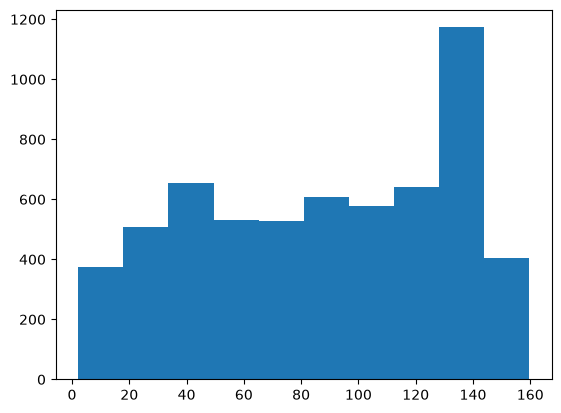

In [185]:
plt.hist(security_traveler_log_df['time_in_system']);

Thre are a lot of people spending more than two hours going through security! And look at that big bump between 130 and 140 minutes!

### Key summary stats

Let's analyze the wait times for each stage in the system.

In [188]:
# Show just the wait time columns
security_traveler_log_df.loc[:, ['wait_for_passport_viewer', 'wait_for_prescreen_help',
                                 'wait_for_human_xray', 'wait_for_bag_xray',
                                 'wait_for_baggage', 'post_xray_time', 'time_in_system']].describe()
    

,wait_for_passport_viewer,wait_for_prescreen_help,wait_for_human_xray,wait_for_bag_xray,wait_for_baggage,post_xray_time,time_in_system
count,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000
mean,79.346191,4.283129,0.142261,0.159804,0.793458,0.996123,87.543836
std,41.622468,3.695767,0.314486,0.320372,1.585686,0.492650,43.275987
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.500045,2.186283
25%,44.167908,0.893643,0.000000,0.000000,0.000000,0.649763,48.828053
50%,78.312062,3.063113,0.000000,0.000000,0.084492,0.846710,89.093096
75%,116.619590,7.918871,0.121165,0.171192,0.695512,1.177082,129.097107
max,148.783249,11.503446,2.575723,2.130544,10.321337,5.417258,159.612644
